# 05 OTOC on a Square Grid

We now do the OTOC anlysis a square lattice.

#### How the OTOC C(t) is performed in the quantum circuit? From Nat 2025

Start from time-order correlator (TOC). $\langle M(t) M \rangle$ measures the correlation between the initial information encoded a $M$ and the information spread deu to the random circuit evolution $U$. Prepare the qubit at an eigenstate of $M$ evolve by $U$ and measure $M$, by averaging over the eigenstates you get the correlator. 
$$
C^{(1)} = \langle M(t) M \rangle = \frac{1}{2} \sum_{m=\pm 1}\langle \psi_m| M(t) M | \psi_m\rangle = \frac{1}{2} \sum_{m=\pm 1}m \langle M_{final} \rangle
$$
at $t= 0 $, $C^{1} = 1$. It decays because info spreads (not in $q_m$), then the overlaps decays. 

For the OTOC, we just insert the butterfly op. into $U$. Now the question is: has the operator at $q_b$ spread enought to overlap with $q_m$ (Does $B(t)$ commutes with $M$?). So, $C^{(2)} = \langle B(t) M B(t) M \rangle$.
Idea: prepare $q_m$, evolve with $U$, perturb with $B$, than reverse and measure M. Does $M$ change due to perturbation?

The generalization comes with the correlator rule $C^{2k} = \langle [B(t) M]^{2k}\rangle$. The following can be obtain from the definition of a nested echo sequence $U_k (t) = B(t) [MB(t)]^{k-1}$ and then $C^{(2k)} = \langle U^{\dagger}_k(t)M U_k(t) M \rangle$. 
In prectice the circuit implementatio becomes: 

prepare $q_m$ - (echo B(t) - M)^(k-1) times - echo B(t) - Measure M$

where echo $B(t) = U B U^\dagger$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

### Building the Square lattice

In [4]:
num_qubits = 9
qubits = [cirq.GridQubit(x,y) for x in range(int(np.sqrt(num_qubits))) for y in range(int(np.sqrt(num_qubits)))]
display(qubits)
probe_idxs = 0,0
side = int(np.sqrt(num_qubits))
def q_idx_list(row,col):
    return row * side + col
probe = q_idx_list(probe_idxs[0], probe_idxs[1])
seed = 3
sampler = cirq.Simulator()
depths = 2
rnd_instances = 10

[cirq.GridQubit(0, 0),
 cirq.GridQubit(0, 1),
 cirq.GridQubit(0, 2),
 cirq.GridQubit(1, 0),
 cirq.GridQubit(1, 1),
 cirq.GridQubit(1, 2),
 cirq.GridQubit(2, 0),
 cirq.GridQubit(2, 1),
 cirq.GridQubit(2, 2)]

In [7]:
def Manhattan_dist(q1, q2):
    dist = np.abs( q2.row - q1.row ) + np.abs( q2.col - q1.col )    
    return int(dist)
dist = Manhattan_dist(qubits[probe], qubits[-1]) 
print(f"The Mdist of {qubits[probe]} and {qubits[-1]} is ", dist)

def Mdist_classification(q1, qubits):
    max_dist = Manhattan_dist(qubits[0], qubits[-1])
    classification = {}
    #creating keys based on max distance
    for key in range(max_dist+1):
        classification[key] = []

    #classifing keys using Mdist
    for q in qubits:
        dist = Manhattan_dist(q1, q)
        classification[dist].append(q)

    #removing empty lists (compact)
    classification = {
        key: values
        for key, values in classification.items()
        if values
    }
    return classification
classification = Mdist_classification(qubits[probe],qubits) 
print(f"The Manhattan distance for the probe qubit {qubits[probe]} are:")
for key,values in classification.items():
    print(f"Distance {key}: {values}")


The Mdist of q(0, 0) and q(2, 2) is  4
The Manhattan distance for the probe qubit q(0, 0) are:
Distance 0: [cirq.GridQubit(0, 0)]
Distance 1: [cirq.GridQubit(0, 1), cirq.GridQubit(1, 0)]
Distance 2: [cirq.GridQubit(0, 2), cirq.GridQubit(1, 1), cirq.GridQubit(2, 0)]
Distance 3: [cirq.GridQubit(1, 2), cirq.GridQubit(2, 1)]
Distance 4: [cirq.GridQubit(2, 2)]


In [8]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit for a square lattice"""
    num_qubits = len(qubits)
    side = int(np.sqrt(num_qubits))
    if not side**2 == num_qubits:
        raise ValueError("Total number of qubits has to be a perfect square") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    c = cirq.Circuit()

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)

        # Horizontal even EG
        for j in range(side):
            for i in range(0, side - 1, 2):
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        
        # Vertical odd EG
        for j in range(1, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
              
        # Horizontal odd EG
        for j in range(side):
            for i in range(1, side - 1, 2): 
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        # Vertical even EG
        for j in range(0, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
    return c

In [44]:
simple_random_circuit(qubits, 1, 5)

┌──┐   ┌──┐       ┌──┐
(0, 0): ───S^-1───────@────────────@──────────
                      │            │
(0, 1): ───X^-0.5─────@──────@─────┼────@─────
                             │     │    │
(0, 2): ───Y^-0.25───────────@─────┼────┼@────
                                   │    ││
(1, 0): ───Y^0.5──────@──────@─────@────┼┼────
                      │      │          ││
(1, 1): ───T──────────@──────┼@────@────@┼────
                             ││    │     │
(1, 2): ───X^0.75──────@─────┼┼────@─────@────
                       │     ││
(2, 0): ───Y^0.75─────@┼─────@┼───────────────
                      ││      │
(2, 1): ───X^0.25─────@┼──────@────@──────────
                       │           │
(2, 2): ───X^0.25──────@───────────@──────────
                     └──┘   └──┘       └──┘

In [87]:
def noiseless_echo_circuit(qubits, depth, probe, seed):
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    return c

def noiseless_perturbed_echo_circuit(qubits, depth, pert, seed):
    """Construting B(t) = U B U^\dagger"""
    c = cirq.Circuit()
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.measure(qubits[pert]))

    c.append(U_t_dagger)
    
    return c

def noiseless_otoc_circuit(qubits, depth, probe, pert, m, k,seed):
    """
    probe: probe qubit
    pert: perturbation qubit for the butterly
    m is the Z eigenvalue = \pm 1
    k is the otoc order 
    """
    #Initializing the circuit
    c = cirq.Circuit()
    
    #Two eigenstates of the Z operator
    if m == 1: 
        c.append(cirq.X(qubits[probe]))
    
    #p(echo B(t) - M)^(k-1) times
    for k_ in range(k-1):
        # B(t)
        c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
        #M 
        c.append(cirq.Z(qubits[probe]))
    
    #B(t)^\dagger = B(t)
    c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
    
    #measure M
    c.append(cirq.measure(qubits[probe], key="z"))
    return c
    

In [88]:
layer = 1
seed = 15
pert_idxs = 2,2
pert = q_idx_list(pert_idxs[0], pert_idxs[1])

#print("Perfect echo")
#display(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)
k, m = 1, 0
print(f"Perturbed OTOC({k}) for m = {m}, #layers = {layer}, b_qubit = {pert_idxs}: ")
display(noiseless_otoc_circuit(qubits, layer, probe, pert, m, k,seed))
k, m = 2, 1
print(f"Perturbed OTOC({k}) for m = {m}, #layers = {layer}, b_qubit = {pert_idxs}: ")
display(noiseless_otoc_circuit(qubits, layer, probe, pert, m, k,seed))

Perturbed OTOC(1) for m = 0, #layers = 1, b_qubit = (2, 2): 


┌──┐   ┌──┐       ┌──┐   ┌──┐       ┌──┐   ┌──┐
(0, 0): ───S^-1───────@────────────@─────────────────@───────────@─────S─────────M('z')───
                      │            │                 │           │
(0, 1): ───S^-1───────@──────@─────┼────@──────@─────┼────@──────@─────S──────────────────
                             │     │    │      │     │    │
(0, 2): ───X^0.75────────────@─────┼────┼@─────┼@────┼────@────────────X^-0.75────────────
                                   │    ││     ││    │
(1, 0): ───X^0.25─────@──────@─────@────┼┼─────┼┼────@────@──────@─────X^-0.25────────────
                      │      │          ││     ││         │      │
(1, 1): ───Y^-0.25────@──────┼@────@────@┼─────@┼────@────┼@─────@─────Y^0.25─────────────
                             ││    │     │      │    │    ││
(1, 2): ───T───────────@─────┼┼────@─────@──────@────@────┼┼──────@────T^-1───────────────
                       │     ││                           ││      │
(2, 0): ───S^-1───────@┼─────@┼───────────────────────────@┼─────@┼────S──────────────────
                      ││      │                            │     ││
(2, 1): ───Y^0.75─────@┼──────@────@─────────────────@─────@─────@┼────Y^-0.75────────────
                       │           │                 │            │
(2, 2): ───Z^0.75──────@───────────@────M────────────@────────────@────Z^-0.75────────────
                     └──┘   └──┘       └──┘   └──┘       └──┘   └──┘

Perturbed OTOC(2) for m = 1, #layers = 1, b_qubit = (2, 2): 


┌──┐   ┌──┐       ┌──┐   ┌──┐       ┌──┐   ┌──┐                           ┌──┐   ┌──┐       ┌──┐   ┌──┐       ┌──┐   ┌──┐
(0, 0): ───X───S^-1───────@────────────@─────────────────@───────────@─────S─────────Z───S^-1───────@────────────@─────────────────@───────────@─────S─────────M('z')───
                          │            │                 │           │                              │            │                 │           │
(0, 1): ───────S^-1───────@──────@─────┼────@──────@─────┼────@──────@─────S─────────────S^-1───────@──────@─────┼────@──────@─────┼────@──────@─────S──────────────────
                                 │     │    │      │     │    │                                            │     │    │      │     │    │
(0, 2): ───────X^0.75────────────@─────┼────┼@─────┼@────┼────@────────────X^-0.75───────X^0.75────────────@─────┼────┼@─────┼@────┼────@────────────X^-0.75────────────
                                       │    ││     ││    │                                                       │    ││     ││    │
(1, 0): ───────X^0.25─────@──────@─────@────┼┼─────┼┼────@────@──────@─────X^-0.25───────X^0.25─────@──────@─────@────┼┼─────┼┼────@────@──────@─────X^-0.25────────────
                          │      │          ││     ││         │      │                              │      │          ││     ││         │      │
(1, 1): ───────Y^-0.25────@──────┼@────@────@┼─────@┼────@────┼@─────@─────Y^0.25────────Y^-0.25────@──────┼@────@────@┼─────@┼────@────┼@─────@─────Y^0.25─────────────
                                 ││    │     │      │    │    ││                                           ││    │     │      │    │    ││
(1, 2): ───────T───────────@─────┼┼────@─────@──────@────@────┼┼──────@────T^-1──────────T───────────@─────┼┼────@─────@──────@────@────┼┼──────@────T^-1───────────────
                           │     ││                           ││      │                              │     ││                           ││      │
(2, 0): ───────S^-1───────@┼─────@┼───────────────────────────@┼─────@┼────S─────────────S^-1───────@┼─────@┼───────────────────────────@┼─────@┼────S──────────────────
                          ││      │                            │     ││                             ││      │                            │     ││
(2, 1): ───────Y^0.75─────@┼──────@────@─────────────────@─────@─────@┼────Y^-0.75───────Y^0.75─────@┼──────@────@─────────────────@─────@─────@┼────Y^-0.75────────────
                           │           │                 │            │                              │           │                 │            │
(2, 2): ───────Z^0.75──────@───────────@────M────────────@────────────@────Z^-0.75───────Z^0.75──────@───────────@────M────────────@────────────@────Z^-0.75────────────
                         └──┘   └──┘       └──┘   └──┘       └──┘   └──┘                           └──┘   └──┘       └──┘   └──┘       └──┘   └──┘

## Proper code 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

In [7]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit for a square lattice"""
    num_qubits = len(qubits)
    side = int(np.sqrt(num_qubits))
    if not side**2 == num_qubits:
        raise ValueError("Total number of qubits has to be a perfect square") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    c = cirq.Circuit()

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)

        # Horizontal even EG
        for j in range(side):
            for i in range(0, side - 1, 2):
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        
        # Vertical odd EG
        for j in range(1, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
              
        # Horizontal odd EG
        for j in range(side):
            for i in range(1, side - 1, 2): 
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        # Vertical even EG
        for j in range(0, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
    return c

In [2]:
def Manhattan_dist(q1, q2):
    dist = np.abs( q2.row - q1.row ) + np.abs( q2.col - q1.col )    
    return int(dist)


def Mdist_classification(q1, qubits):
    max_dist = Manhattan_dist(qubits[0], qubits[-1])
    classification = {}
    #creating keys based on max distance
    for key in range(max_dist+1):
        classification[key] = []

    #classifing keys using Mdist
    for q in qubits:
        dist = Manhattan_dist(q1, q)
        classification[dist].append(q)

    #removing empty lists (compact)
    classification = {
        key: values
        for key, values in classification.items()
        if values
    }
    return classification

In [3]:
def noiseless_echo_circuit(qubits, depth, probe, seed):
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    return c

def noiseless_perturbed_echo_circuit(qubits, depth, pert, seed):
    """Construting B(t) = U^\dagger B U"""
    c = cirq.Circuit()
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.measure(qubits[pert]))

    c.append(U_t_dagger)
    
    return c

def noiseless_otoc_circuit(qubits, depth, probe, pert, m, k,seed):
    """
    probe: probe qubit
    pert: perturbation qubit for the butterly
    m is the Z eigenvalue = \pm 1
    k is the otoc order 
    """
    #Initializing the circuit
    c = cirq.Circuit()
    
    #Two eigenstates of the Z operator
    if m == -1: 
        c.append(cirq.X(qubits[probe]))
    
    #p(echo B(t) - M)^(k-1) times
    for k_ in range(k-1):
        # B(t)
        c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
        #M 
        c.append(cirq.Z(qubits[probe]))
    
    #B(t)^\dagger = B(t)
    c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
    
    #measure M
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    #counts = results.measurements["z"]
    counts = results.records["z"][:, 0, 0]
    return counts

In [8]:
num_qubits = 9
qubits = [cirq.GridQubit(x,y) for x in range(int(np.sqrt(num_qubits))) for y in range(int(np.sqrt(num_qubits)))]
probe_idxs = 0,0
side = int(np.sqrt(num_qubits))
def q_idx_list(row,col):
    return row * side + col
probe = q_idx_list(probe_idxs[0], probe_idxs[1])
seed = 3
sampler = cirq.Simulator()
depths = 15
rnd_instances = 20
k = 1

classification = Mdist_classification(qubits[probe],qubits) 
print(f"The Manhattan distances for the probe qubit {qubits[probe]} are: \n")
for key,values in classification.items():
    print(f"Distance {key}: {values}")
count_avg_un_p_s = [np.zeros(depths) for i in range(len(classification))]
count_avg_p_s = [np.zeros(depths) for i in range(len(classification))]

The Manhattan distances for the probe qubit q(0, 0) are: 

Distance 0: [cirq.GridQubit(0, 0)]
Distance 1: [cirq.GridQubit(0, 1), cirq.GridQubit(1, 0)]
Distance 2: [cirq.GridQubit(0, 2), cirq.GridQubit(1, 1), cirq.GridQubit(2, 0)]
Distance 3: [cirq.GridQubit(1, 2), cirq.GridQubit(2, 1)]
Distance 4: [cirq.GridQubit(2, 2)]


In [ ]:
for key,values in classification.items():
    # Every qubit with the same Mdist
    count_avg_sameMdist_unp_qs = np.zeros((depths,len(values)))
    count_avg_sameMdist_p_qs = np.zeros((depths,len(values)))
    for idx,pert_q in enumerate(values):
        pert = q_idx_list(pert_q.row, pert_q.col)
        count_avg_un_p, count_avg_p = np.zeros(depths), np.zeros(depths)
        #Every layer for the same pert qubit
        for layer in range(depths):
            count_un_p, count_p = 0., 0.
            #Rand instances for statistics
            for seed in range(rnd_instances):
                #count_un_p += np.mean(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)[0]                
                z_p = (1 - 2*np.mean(noiseless_otoc_circuit(qubits, layer, probe, pert, 1, k, seed)))
                count_p += (+1)*z_p/2
                z_m = (1 - 2*np.mean(noiseless_otoc_circuit(qubits, layer, probe, pert, -1, k, seed)))
                count_p += (-1)*z_m/2

            #count_un_p /= rnd_instances
            count_p /= rnd_instances
            #count_avg_sameMdist_unp_qs[layer,idx] = count_un_p
            count_avg_sameMdist_p_qs[layer,idx] = count_p
    
    #count_avg_un_p_s[key] = np.sum(count_avg_sameMdist_unp_qs, axis=1)/len(values)
    count_avg_p_s[key] = np.sum(count_avg_sameMdist_p_qs, axis=1)/len(values)

(-0.5, 20.0)

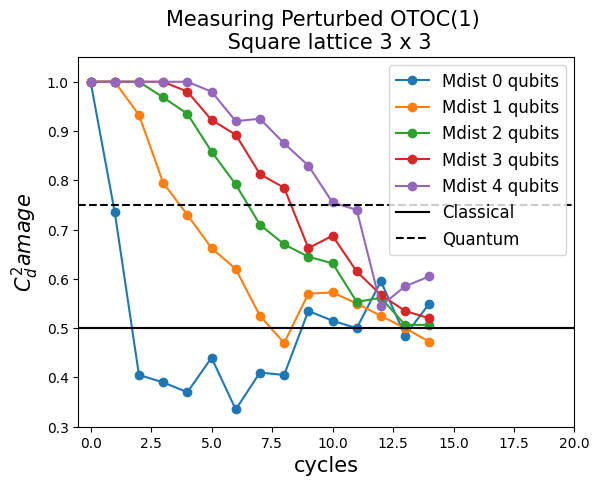

In [ ]:
fontsize_plot = 15
for key,values in classification.items():
    #if key ==0:
        #plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black", label="Unperturbed")
    #else:
        #plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black")
    plt.plot(range(depths), count_avg_p_s[key], "-o", label=f"Mdist {key} qubits")

plt.axhline(0, label= "Classical", color = "black")
plt.axhline(1/2, linestyle = "--",label= "Quantum", color = "black")
plt.title(f"Measuring Perturbed OTOC({k}) \n Square lattice {side} x {side}", fontsize= fontsize_plot)
plt.xlabel("cycles", fontsize= fontsize_plot)
plt.ylabel(rf"$C^{{{2*k}}}_{{damage}}$"why, fontsize= fontsize_plot)
plt.legend(fontsize =fontsize_plot-3, loc="upper right", ncol=1)
plt.ylim(0.3, 1.05)
plt.xlim(-0.5, 20)


## Butterfly Z

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

In [118]:
def Manhattan_dist(q1, q2):
    dist = np.abs( q2.row - q1.row ) + np.abs( q2.col - q1.col )    
    return int(dist)


def Mdist_classification(q1, qubits):
    max_dist = Manhattan_dist(qubits[0], qubits[-1])
    classification = {}
    #creating keys based on max distance
    for key in range(max_dist+1):
        classification[key] = []

    #classifing keys using Mdist
    for q in qubits:
        dist = Manhattan_dist(q1, q)
        classification[dist].append(q)

    #removing empty lists (compact)
    classification = {
        key: values
        for key, values in classification.items()
        if values
    }
    return classification

In [119]:
def noiseless_perturbed_echo_circuit(qubits, depth, pert, seed):
    """Construting B(t) = U^\dagger B U"""
    c = cirq.Circuit()
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.Z(qubits[pert]))

    c.append(U_t_dagger)
    
    return c

def noiseless_otoc_circuit(qubits, depth, probe, pert, m, k,seed):
    """
    probe: probe qubit
    pert: perturbation qubit for the butterly
    m is the Z eigenvalue = \pm 1
    k is the otoc order 
    """
    #Initializing the circuit
    c = cirq.Circuit()
    
    #Two eigenstates of the Z operator
    if m == -1: 
        c.append(cirq.X(qubits[probe]))
    
    #p(echo B(t) - M)^(k-1) times
    for k_ in range(k-1):
        # B(t)
        c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
        #M 
        c.append(cirq.Z(qubits[probe]))
    
    #B(t)^\dagger = B(t)
    c.append(noiseless_perturbed_echo_circuit(qubits, depth, pert, seed))
    
    #measure M
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    #counts = results.measurements["z"]
    counts = results.records["z"][:, 0, 0]
    return counts

In [120]:
num_qubits = 9
qubits = [cirq.GridQubit(x,y) for x in range(int(np.sqrt(num_qubits))) for y in range(int(np.sqrt(num_qubits)))]
probe_idxs = 0,0
side = int(np.sqrt(num_qubits))
def q_idx_list(row,col):
    return row * side + col
probe = q_idx_list(probe_idxs[0], probe_idxs[1])
seed = 3
sampler = cirq.Simulator()
depths = 15
rnd_instances = 20
k = 1

classification = Mdist_classification(qubits[probe],qubits) 
print(f"The Manhattan distances for the probe qubit {qubits[probe]} are: \n")
for key,values in classification.items():
    print(f"Distance {key}: {values}")
count_avg_un_p_s = [np.zeros(depths) for i in range(len(classification))]
count_avg_p_s = [np.zeros(depths) for i in range(len(classification))]

The Manhattan distances for the probe qubit q(0, 0) are: 

Distance 0: [cirq.GridQubit(0, 0)]
Distance 1: [cirq.GridQubit(0, 1), cirq.GridQubit(1, 0)]
Distance 2: [cirq.GridQubit(0, 2), cirq.GridQubit(1, 1), cirq.GridQubit(2, 0)]
Distance 3: [cirq.GridQubit(1, 2), cirq.GridQubit(2, 1)]
Distance 4: [cirq.GridQubit(2, 2)]


In [121]:
for key,values in classification.items():
    # Every qubit with the same Mdist
    count_avg_sameMdist_unp_qs = np.zeros((depths,len(values)))
    count_avg_sameMdist_p_qs = np.zeros((depths,len(values)))
    for idx,pert_q in enumerate(values):
        pert = q_idx_list(pert_q.row, pert_q.col)
        count_avg_un_p, count_avg_p = np.zeros(depths), np.zeros(depths)
        #Every layer for the same pert qubit
        for layer in range(depths):
            count_un_p, count_p = 0., 0.
            #Rand instances for statistics
            for seed in range(rnd_instances):
                #count_un_p += np.mean(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)[0]                
                z_p = (1 - 2*np.mean(noiseless_otoc_circuit(qubits, layer, probe, pert, 1, k, seed)))
                count_p += (+1)*z_p/2
                z_m = (1 - 2*np.mean(noiseless_otoc_circuit(qubits, layer, probe, pert, -1, k, seed)))
                count_p += (-1)*z_m/2

            #count_un_p /= rnd_instances
            count_p /= rnd_instances
            #count_avg_sameMdist_unp_qs[layer,idx] = count_un_p
            count_avg_sameMdist_p_qs[layer,idx] = count_p
    
    #count_avg_un_p_s[key] = np.sum(count_avg_sameMdist_unp_qs, axis=1)/len(values)
    count_avg_p_s[key] = np.sum(count_avg_sameMdist_p_qs, axis=1)/len(values)

(-0.5, 20.0)

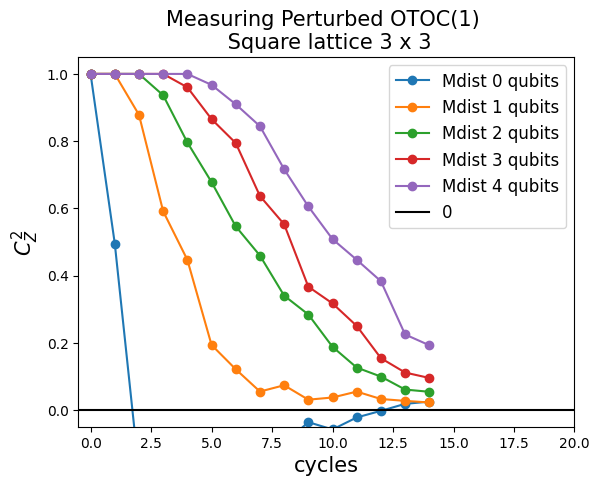

In [127]:
fontsize_plot = 15
for key,values in classification.items():
    #if key ==0:
        #plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black", label="Unperturbed")
    #else:
        #plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black")
    plt.plot(range(depths), count_avg_p_s[key], "-o", label=f"Mdist {key} qubits")

plt.axhline(0, label= "0", color = "black")
#plt.axhline(1/2, linestyle = "--",label= "Quantum", color = "black")
plt.title(f"Measuring Perturbed OTOC({k}) \n Square lattice {side} x {side}", fontsize= fontsize_plot)
plt.xlabel("cycles", fontsize= fontsize_plot)
plt.ylabel(rf"$C^{(2*k)}_Z$", fontsize= fontsize_plot)
plt.legend(fontsize =fontsize_plot-3, loc="upper right", ncol=1)
plt.ylim(-0.05, 1.05)
plt.xlim(-0.5, 20)
